In [1]:
import numpy as np

# 定义向量和矩阵
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])

# 1. 向量点积
dot_product = np.dot(a, b)
print("向量点积 a·b =", dot_product)

# 2. 矩阵乘法 A × B
matrix_product = np.dot(A, B)
print("矩阵乘法 A×B：\n", matrix_product)
print("结果矩阵的形状：", matrix_product.shape)

# 3. 向量 a 的 Frobenius 范数
frobenius_norm = np.linalg.norm(a)
print("向量 a 的 Frobenius 范数 =", frobenius_norm)

向量点积 a·b = -8
矩阵乘法 A×B：
 [[ 8  5]
 [ 1 -2]]
结果矩阵的形状： (2, 2)
向量 a 的 Frobenius 范数 = 3.7416573867739413


In [2]:
import numpy as np

# 1. 创建一个形状为 3×4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("矩阵 X (3×4，标准正态分布):\n", X)

# 2. 创建一个形状为 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n矩阵 Y (4×2，全1矩阵):\n", Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("\n矩阵 Z = X × Y:\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
# 注意：Python 索引从 0 开始，所以“第一行”对应索引 0，“第二列”对应索引 1
element = Z[0, 1]
second_row = Z[1, :]
print("\nZ 的第一行第二列元素:", element)
print("Z 的第 2 行所有元素:", second_row)

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z)
print("\nZ 的 Frobenius 范数:", frobenius_norm)

矩阵 X (3×4，标准正态分布):
 [[-1.32484494  2.06186132  1.44024405  1.0759136 ]
 [ 0.53609136  1.10606785  0.05152458 -0.67399411]
 [ 0.47911703 -1.02396273  0.92114814 -0.03383068]]

矩阵 Y (4×2，全1矩阵):
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z = X × Y:
 [[3.25317403 3.25317403]
 [1.01968968 1.01968968]
 [0.34247177 0.34247177]]

Z 的第一行第二列元素: 3.253174030364582
Z 的第 2 行所有元素: [1.01968968 1.01968968]

Z 的 Frobenius 范数: 4.845656863170943


d:\Anaconda\envs\Anacondazhang\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\Anacondazhang\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\Anacondazhang\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\Anacondazhang\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\Anacondazhang\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) m

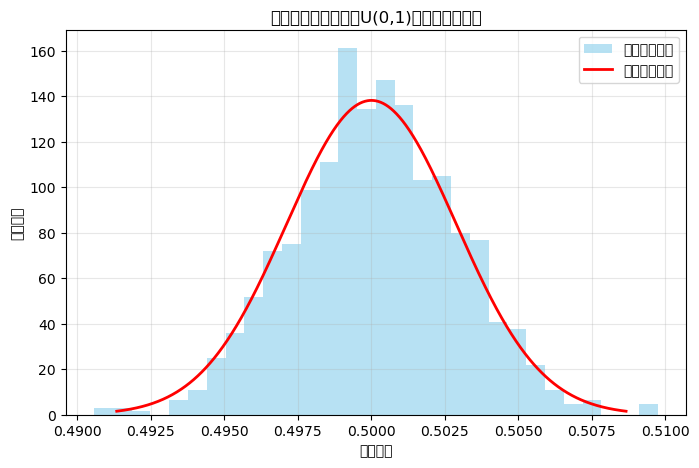

理论方差: 0.00000833
实际方差: 0.00000784


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成数据：m次重复，每次取n个U(0,1)变量，计算均值
n = 10000   # 每次的样本量
m = 1000    # 重复次数

# 生成m个均值
means = []
for _ in range(m):
    samples = np.random.uniform(0, 1, size=n)
    means.append(np.mean(samples))
means = np.array(means)

# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(8, 5))
# 直方图
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', label='模拟均值分布')

# 理论正态分布参数
# U(0,1)的均值μ=0.5，方差σ²=1/12
# 均值的理论分布：N(μ, σ²/n)
mu_theory = 0.5
var_theory = (1/12) / n
std_theory = np.sqrt(var_theory)

# 生成理论正态分布曲线
x = np.linspace(mu_theory - 3*std_theory, mu_theory + 3*std_theory, 1000)
y = norm.pdf(x, loc=mu_theory, scale=std_theory)
plt.plot(x, y, 'r-', lw=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理模拟（U(0,1)样本均值分布）')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差
actual_var = np.var(means, ddof=1)  # 无偏方差
print(f"理论方差: {var_theory:.8f}")
print(f"实际方差: {actual_var:.8f}")

In [4]:
import torch

# 定义变量，设置 requires_grad=True
x = torch.tensor(2.0)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 前向传播
a = x * w1
b = a + w2
L = b ** 2

# 反向传播
L.backward()

# 输出结果
print("前向结果 L =", L.item())
print("dL/dw1 =", w1.grad.item())
print("dL/dw2 =", w2.grad.item())

前向结果 L = 12.25
dL/dw1 = 14.0
dL/dw2 = 7.0


In [5]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# ---------------------- 1. 加载数据 ----------------------
data = load_digits()
X = data.data       # 图像数据 (1797, 64)
y = data.target     # 标签 (1797,)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 数据归一化（0~1）
X_train = X_train / 16.0
X_test = X_test / 16.0

# ---------------------- 2. 标签 one-hot 编码 ----------------------
def one_hot_encode(labels, num_classes=10):
    return np.eye(num_classes)[labels]

y_train_onehot = one_hot_encode(y_train)
y_test_onehot = one_hot_encode(y_test)

# ---------------------- 3. 实现 softmax 和交叉熵损失 ----------------------
def softmax(z):
    # 防止数值溢出，减去每行最大值
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # 防止 log(0)
    epsilon = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + epsilon), axis=1))

# ---------------------- 4. 初始化参数与训练 ----------------------
n_features = X_train.shape[1]   # 64
n_classes = 10
lr = 0.1
batch_size = 32
epochs = 50

# 初始化权重和偏置
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

n_train = X_train.shape[0]

for epoch in range(epochs):
    # 打乱数据
    permutation = np.random.permutation(n_train)
    X_shuffled = X_train[permutation]
    y_shuffled = y_train_onehot[permutation]
    
    for i in range(0, n_train, batch_size):
        # 取小批量
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        z = X_batch @ W + b
        y_pred = softmax(z)
        
        # 反向传播：计算梯度
        dz = (y_pred - y_batch) / batch_size
        dW = X_batch.T @ dz
        db = np.sum(dz, axis=0, keepdims=True)
        
        # 更新参数
        W -= lr * dW
        b -= lr * db
    
    # 每个 epoch 输出损失
    z_train = X_train @ W + b
    y_train_pred = softmax(z_train)
    loss = cross_entropy_loss(y_train_pred, y_train_onehot)
    print(f"Epoch {epoch+1:2d}/{epochs}, 训练损失: {loss:.4f}")

# ---------------------- 5. 测试集准确率 ----------------------
z_test = X_test @ W + b
y_test_pred = softmax(z_test)
y_pred_labels = np.argmax(y_test_pred, axis=1)
accuracy = np.mean(y_pred_labels == y_test)

print(f"\n测试集准确率: {accuracy:.4f}")

Epoch  1/50, 训练损失: 1.6057
Epoch  2/50, 训练损失: 1.1948
Epoch  3/50, 训练损失: 0.9462
Epoch  4/50, 训练损失: 0.7882
Epoch  5/50, 训练损失: 0.6838
Epoch  6/50, 训练损失: 0.6059
Epoch  7/50, 训练损失: 0.5486
Epoch  8/50, 训练损失: 0.5050
Epoch  9/50, 训练损失: 0.4688
Epoch 10/50, 训练损失: 0.4396
Epoch 11/50, 训练损失: 0.4146
Epoch 12/50, 训练损失: 0.3934
Epoch 13/50, 训练损失: 0.3753
Epoch 14/50, 训练损失: 0.3596
Epoch 15/50, 训练损失: 0.3459
Epoch 16/50, 训练损失: 0.3338
Epoch 17/50, 训练损失: 0.3219
Epoch 18/50, 训练损失: 0.3121
Epoch 19/50, 训练损失: 0.3025
Epoch 20/50, 训练损失: 0.2941
Epoch 21/50, 训练损失: 0.2879
Epoch 22/50, 训练损失: 0.2792
Epoch 23/50, 训练损失: 0.2728
Epoch 24/50, 训练损失: 0.2667
Epoch 25/50, 训练损失: 0.2607
Epoch 26/50, 训练损失: 0.2554
Epoch 27/50, 训练损失: 0.2505
Epoch 28/50, 训练损失: 0.2460
Epoch 29/50, 训练损失: 0.2415
Epoch 30/50, 训练损失: 0.2371
Epoch 31/50, 训练损失: 0.2339
Epoch 32/50, 训练损失: 0.2295
Epoch 33/50, 训练损失: 0.2258
Epoch 34/50, 训练损失: 0.2224
Epoch 35/50, 训练损失: 0.2190
Epoch 36/50, 训练损失: 0.2160
Epoch 37/50, 训练损失: 0.2130
Epoch 38/50, 训练损失: 0.2101
Epoch 39/50,

Epoch  100/1000, Loss: 0.0301
Epoch  200/1000, Loss: 0.0200
Epoch  300/1000, Loss: 0.0161
Epoch  400/1000, Loss: 0.0139
Epoch  500/1000, Loss: 0.0125
Epoch  600/1000, Loss: 0.0114
Epoch  700/1000, Loss: 0.0107
Epoch  800/1000, Loss: 0.0100
Epoch  900/1000, Loss: 0.0095
Epoch 1000/1000, Loss: 0.0091


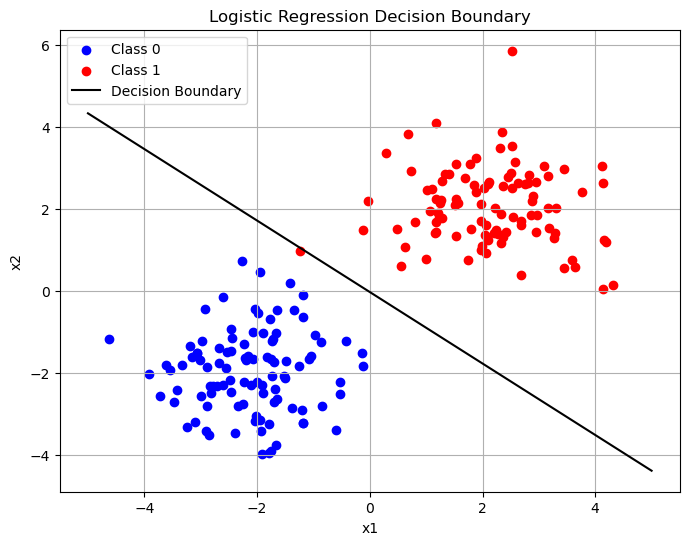

测试集准确率: 0.9900


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 生成线性可分数据 ----------------------
np.random.seed(42)
n_samples = 200
# 类别0：均值(-2,-2)，方差1
X0 = np.random.randn(n_samples//2, 2) + np.array([-2, -2])
y0 = np.zeros(n_samples//2)
# 类别1：均值(2,2)，方差1
X1 = np.random.randn(n_samples//2, 2) + np.array([2, 2])
y1 = np.ones(n_samples//2)

# 合并数据
X = np.vstack((X0, X1))
y = np.hstack((y0, y1)).reshape(-1, 1)

# ---------------------- 2. 定义sigmoid和交叉熵损失 ----------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(y_pred, y_true):
    epsilon = 1e-9  # 防止log(0)
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

# ---------------------- 3. 梯度下降训练 ----------------------
# 初始化参数
n_features = X.shape[1]
w = np.zeros((n_features, 1))
b = 0
lr = 0.1
epochs = 1000

for i in range(epochs):
    # 前向传播
    z = X @ w + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = cross_entropy_loss(y_pred, y)
    
    # 反向传播求梯度
    dw = (X.T @ (y_pred - y)) / n_samples
    db = np.mean(y_pred - y)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1:4d}/{epochs}, Loss: {loss:.4f}")

# ---------------------- 4. 绘制决策边界 ----------------------
plt.figure(figsize=(8, 6))
# 绘制数据点
plt.scatter(X0[:, 0], X0[:, 1], c='blue', label='Class 0')
plt.scatter(X1[:, 0], X1[:, 1], c='red', label='Class 1')

# 绘制决策边界：w1*x1 + w2*x2 + b = 0
x1 = np.linspace(-5, 5, 100)
x2 = (-w[0,0]*x1 - b) / w[1,0]
plt.plot(x1, x2, 'k-', label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.grid(True)
plt.show()

# ---------------------- 5. 测试集准确率 ----------------------
# 生成测试数据
X0_test = np.random.randn(50, 2) + np.array([-2, -2])
X1_test = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack((X0_test, X1_test))
y_test = np.hstack((np.zeros(50), np.ones(50))).reshape(-1, 1)

# 预测
z_test = X_test @ w + b
y_pred_proba = sigmoid(z_test)
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = np.mean(y_pred == y_test)
print(f"测试集准确率: {accuracy:.4f}")

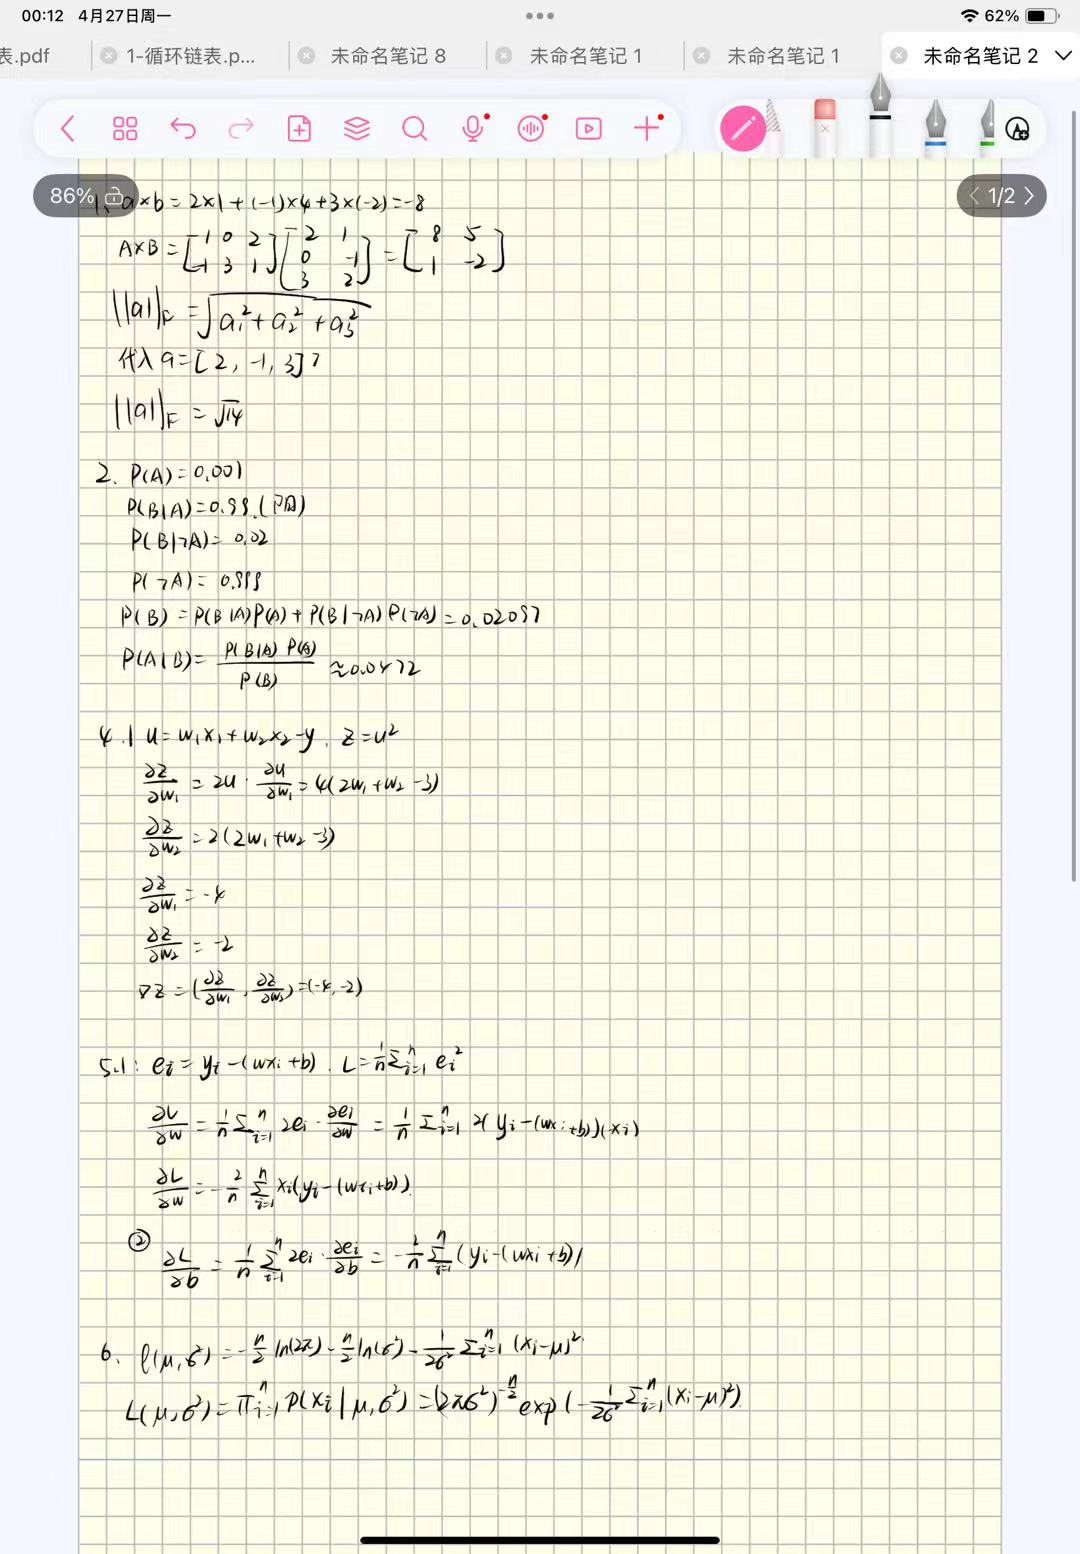